In [1]:
import pandas as pd
import numpy as np
import mglearn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

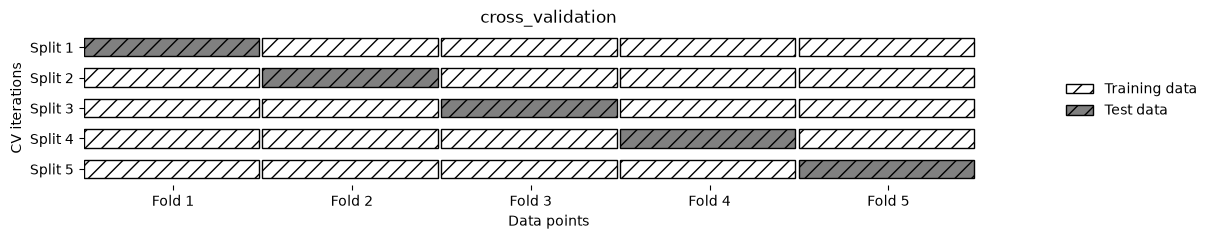

In [2]:
#K分割交差検証
mglearn.plots.plot_cross_validation()

In [3]:
#scikit-learnでの交差検証

from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

iris = load_iris()
logreg = LogisticRegression(max_iter=1000)

#デフォルトの分割数は5である。交差検証の結果は、各分割における精度の配列として返される。
scores = cross_val_score(logreg,iris.data,iris.target,cv=5)

print("Cross-validation scores:{}".format(scores))

Cross-validation scores:[0.96666667 1.         0.93333333 0.96666667 1.        ]


In [4]:
#交差検証の精度をまとめるには、一般に平均値を用いる
print("Average cross-validation score:{:.2f}".format(scores.mean()))

Average cross-validation score:0.97


In [5]:
#単純なK分割交差検証では、各分割におけるクラスの割合が全体のクラスの割合と同じになるとは限らない。
#クラス分類気の場合、層化K分割交差検証を用いるのが一般的である。
# 層化K分割交差検証では、各分割におけるクラスの割合が全体のクラスの割合と同じになるように分割される。

print("Iris labels:\n{}".format(iris.target))

Iris labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


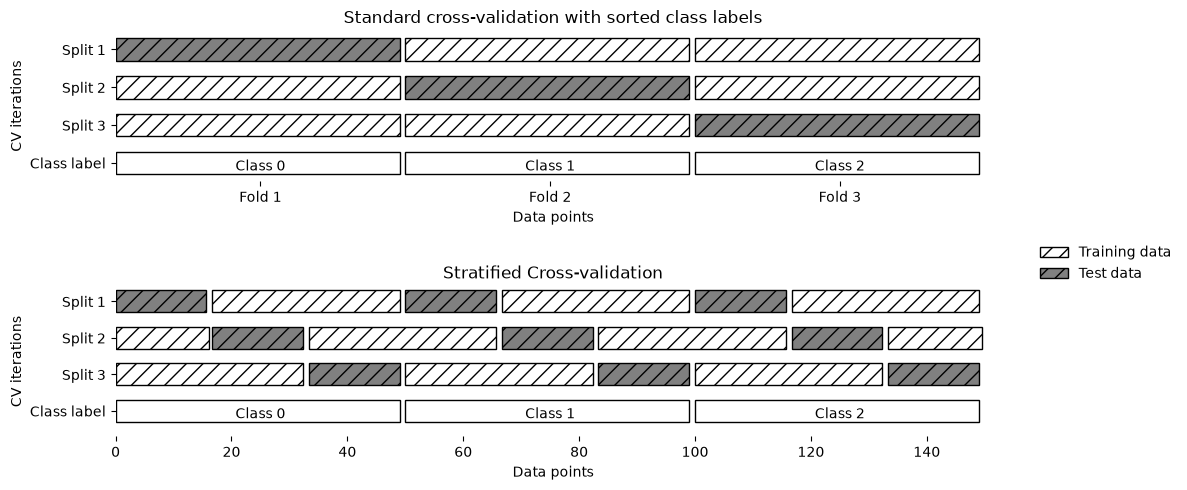

In [6]:
mglearn.plots.plot_stratified_cross_validation()

In [7]:
#交差検証のより詳細な制御のために、cvパラメータにKFoldクラスのインスタンスを渡すことができる。

from sklearn.model_selection import KFold
kfold = KFold(n_splits=5)

print("Cross-vaidation scores:\n{}".format(
    cross_val_score(logreg,iris.data,iris.target,cv=kfold)
))

Cross-vaidation scores:
[1.         1.         0.86666667 0.93333333 0.83333333]


In [8]:
#三分割の層化されていない交差検証をirisデータっとに使うとひどいことになることを確認してみる
#そのため、層化k分割交差検証を使うためにStratifiedKFoldクラスを使う

kfold = KFold(n_splits=3)
print("Cross-validation scores:\n{}".format(
    cross_val_score(logreg,iris.data,iris.target,cv=kfold)
))

Cross-validation scores:
[0. 0. 0.]


In [9]:
#分割前にデータをシャッフルしてみる
kfold = KFold(
    n_splits=3,
    shuffle=True,
    random_state=0
)

print("Cross-validation scores:\n{}".format(
    cross_val_score(logreg,iris.data,iris.target,cv=kfold)
))

Cross-validation scores:
[0.98 0.96 0.96]


In [10]:
# 一つ抜き交差検証（Leave-One-Out Cross Validation）
# データを1つだけテストデータにし、残りすべてを訓練データとして評価する
# これを全データが1回ずつテストデータになるまで繰り返す
# データ数をnとすると、n回モデルを学習する（k分割交差検証のk=nに相当）
# 訓練データを最大限利用できるが、データ数が多いと計算量が大きくなる

from sklearn.model_selection import LeaveOneOut
loo = LeaveOneOut()
scores = cross_val_score(
    logreg, iris.data, iris.target, cv=loo
)
print("Number of cv iterations:`{}".format(len(scores)))
print("Mean accuracy:{:.2f}".format(scores.mean()))


Number of cv iterations:`150
Mean accuracy:0.97


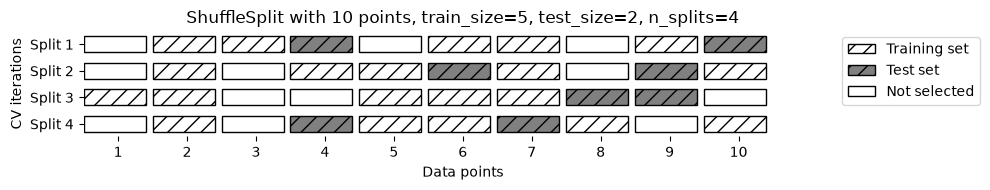

In [11]:
# シャッフル分割交差検証（ShuffleSplit）
# データをランダムにシャッフルし、指定した割合で訓練データとテストデータに分割する
# このランダムな分割を指定した回数だけ繰り返してモデルを評価する
# 通常のk分割と異なり、同じデータが複数回テストデータになったり、一度もならないこともある
#層化バージョンもある

#１０点に対するtrain_size=5,test_size=2のシャッフル分割交差検証を5回繰り返す例
mglearn.plots.plot_shuffle_split()

In [12]:
#データセット50パーセントを訓練セットに、50パーセントをテストセットにして１０回分割を繰り返してみる
from sklearn.model_selection import ShuffleSplit
shuffle_split = ShuffleSplit(
    test_size=0.5,
    train_size=0.5,
    n_splits=10
)

scores = cross_val_score(
    logreg,
    iris.data,
    iris.target,
    cv=shuffle_split  
)

print("Cross-validation scores:\n{}".format(scores))

Cross-validation scores:
[0.94666667 0.97333333 0.97333333 0.96       1.         0.97333333
 0.94666667 0.97333333 0.96       0.97333333]


In [14]:
# グループ付き交差検証（GroupKFold）
# 同じグループに属するデータが、訓練データとテストデータに分かれないように交差検証を行う
# 同一人物から複数のデータを取得した場合など、互いに関連するデータがあるときに使用する
# データリークを防ぎ、未知のグループに対する性能を評価できる

from sklearn.model_selection import GroupKFold
from sklearn.datasets import make_blobs

#合成データセットを生成
x,y  = make_blobs(n_samples=12,random_state=0)

#最初の3サンプルが同じグループに、次の４つが同じグループになるようにする
groups = [0,0,0,1,1,1,1,2,2,3,3,3]
scores = cross_val_score(
    logreg,
    x,
    y,
    groups=groups,
    cv=GroupKFold(n_splits=3)
)

print("Cross-validation scores:\n{}".format(scores))


Cross-validation scores:
[0.75       0.6        0.66666667]


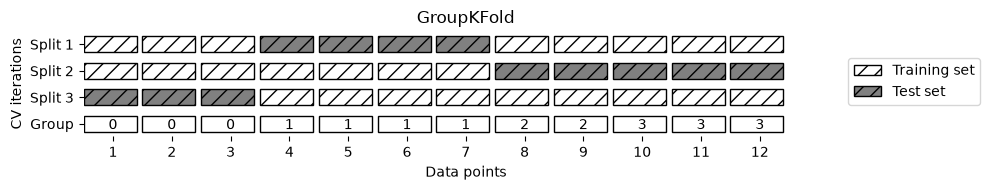

In [ ]:
#個々のグループは、完全に訓練セットに入ってるか、完全にテストセットに入っているかのどちらかになる
mglearn.plots.plot_group_kfold()

**グリッドリサーチ**

In [18]:
#グリッドリサーチは基本的にはパラメータの組み合わせを総当たりで試す方法である

#単純なグリッドサーチ
from sklearn.svm import SVC

x_train,x_test,y_train,y_test = train_test_split(
    iris.data,
    iris.target,
    random_state=0
)

print("Size of training set:{}".format(x_train.shape[0]))
print("Size of test set:{}".format(x_test.shape[0]))

best_score = 0

for gamma in [0.001,0.01,0.1,1,10,100]:
    for C in [0.001,0.01,0.1,1,10,100]:
        svm = SVC(gamma=gamma,C=C)
        svm.fit(x_train,y_train)
        score = svm.score(x_test,y_test)
        if score > best_score:
            best_score = score
            best_parameters = {'C':C,'gamma':gamma}

print("Best score:{:.2f}".format(best_score))
print("Best parameters:{}".format(best_parameters))

Size of training set:112
Size of test set:38
Best score:0.97
Best parameters:{'C': 100, 'gamma': 0.001}


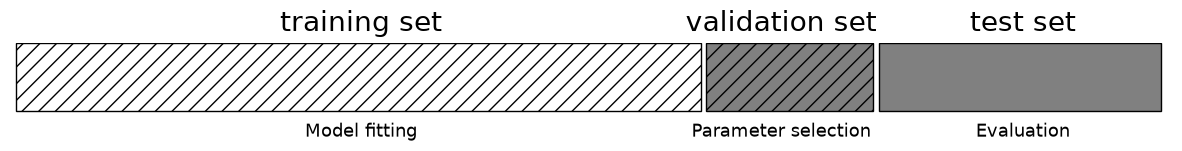

In [19]:
#訓練セット、検証セット、テストセットに分割
#訓練セットで学習し、検証セットでハイパーパラメータを調整し、最終的にテストセットで評価する

mglearn.plots.plot_threefold_split()

In [ ]:
#実装してみる
from sklearn.svm import SVC

#データを訓練＋検証セットとテストセットに分割する
x_trainval,x_test,y_trainval,y_test = train_test_split(
    iris.data,
    iris.target,
    random_state=0
)

#訓練＋検証セットを訓練セットと検証セットに分割する
x_train,x_valid,y_train,y_valid = train_test_split(
    x_trainval,
    y_trainval,
    random_state=1
)

print("Size of training set:{}".format(x_train.shape[0]))
print("Size of validation set:{}".format(x_valid.shape[0]))
print("Size of test set:{}".format(x_test.shape[0]))

best_score = 0

for gamma in [0.001,0.01,0.1,1,10,100]:
    for C in [0.001,0.01,0.1,1,10,100]:
        svm = SVC(gamma=gamma,C=C)
        svm.fit(x_train,y_train)
        score = svm.score(x_valid,y_valid)
        if score > best_score:
            best_score = score
            best_parameters = {'C':C,'gamma':gamma}

#訓練セットと検証セットを用いてモデルを再構築し、テストセットで評価
svm = SVC(**best_parameters)    # ** → 辞書をキーワード引数として展開
svm.fit(x_trainval,y_trainval)
test_score = svm.score(x_test,y_test)

print("Best score on validation set:{:.2f}".format(best_score))
print("Best parameters:{}".format(best_parameters))
print("Test set score with best parameters:{:.2f}".format(test_score))

Size of training set:84
Size of validation set:28
Size of test set:38
Best score on validation set:0.96
Best parameters:{'C': 10, 'gamma': 0.001}
Test set score with best parameters:0.92


In [ ]:
#交差検証を用いたグリッドサーチ

#訓練セットと検証セットの分割を一度だけ行うのではなく、それぞれのパラメータの組み合わせに対して交差検証を行えばいい
for gamma in [0.001,0.01,0.1,1,10,100]:
    for C in [0.001,0.01,0.1,1,10,100]:
        svm = SVC(gamma=gamma,C=C)
        #交差検証を行う
        scores = cross_val_score(svm,x_trainval,y_trainval,cv=5)
        #交差検証制度の平均を計算する
        score = np.mean(scores)
        if score > best_score:
            best_score = score
            best_parameters = {'C':C,'gamma':gamma}

#訓練セットと検証セットを用いてモデルを再構築し、テストセットで評価
svm = SVC(**best_parameters)
svm.fit(x_trainval,y_trainval)

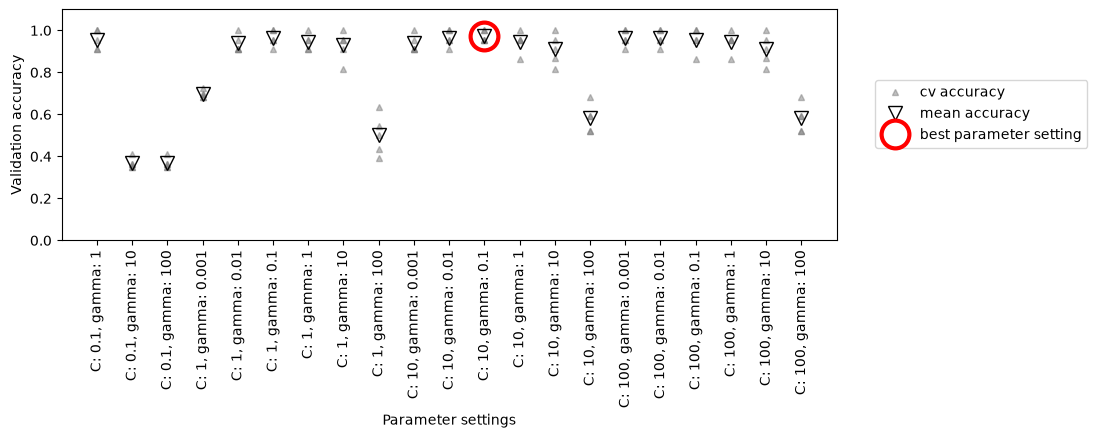

In [22]:
#上に示したコードで最良のパラメータ設定が選択される様子を示す
mglearn.plots.plot_cross_val_selection()

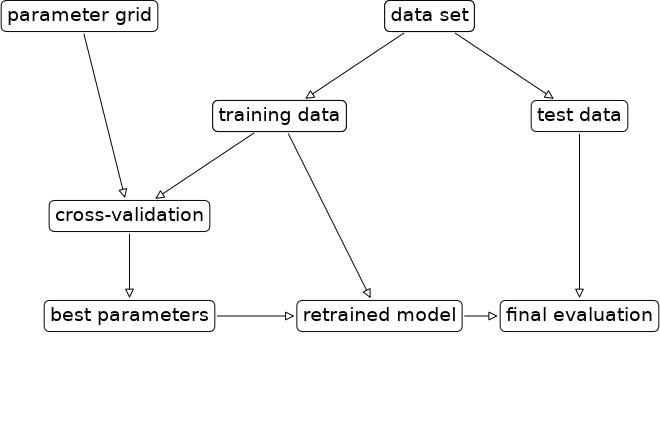

In [23]:
#データを分割し、グリッドリサーチを行い、最後のパラメータを評価する過程を示す
mglearn.plots.plot_grid_search_overview()

In [24]:
#交差検証を用いたグリッドリサーチは、非常に一般的なパラメータチューニングに使われるので、
# scikit-learnではGridSearchCVクラスを使うことで簡単に実装できる

#GridSearchCVクラスを使うには、まずディクショナリを用いて探索したいパラメータを指定する
param_grid = {
    "C" : [0.001,0.01,0.1,1,10,100],
    "gamma" : [0.001,0.01,0.1,1,10,100]
}

print("Parameter grid:\n{}".format(param_grid))

Parameter grid:
{'C': [0.001, 0.01, 0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1, 10, 100]}


In [29]:
#サーチすべきパラメータのグリッド、使用したい交差検証戦略を指定してインスタンスを生成する
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

grid_search = GridSearchCV(
    SVC(),
    param_grid=param_grid,
    cv=5
)

#訓練セットと検証セットを分割する代わりに交差検証を行う
#しかし、パラメータの過剰適合を防ぐためには、さらに訓練セットとテストセットに分割しておく

x_trainval,x_test,y_trainval,y_test = train_test_split(
    iris.data,
    iris.target,
    random_state=0
)

#fitメソッドを呼び出すと、最適なパラメータ設定をサーチするだけではなく、交差検証で最も良いスコアだったパラメータを用いて、
#自動的に訓練セット全体に対して新しいモデルを学習してくれる
grid_search.fit(x_trainval,y_trainval)

print("Test set score:{:.2f}".format(grid_search.score(x_test,y_test)))



Test set score:0.97


In [ ]:
#見つけたパラメータはbest_params_属性に格納
#(訓練セットに対する)交差検証精度はbest_score_属性に格納

print("Best parameters{}".format(grid_search.best_params_))
print("Best cross-validation score:{:.2f}".format(grid_search.best_score_))

Best parameters{'C': 10, 'gamma': 0.1}
Best cross-validation score:0.97
